# DineIQ Analytics — Customer Segmentation & RFM Behavioral Profiling

**Objective:** Calculate and analyze Recency, Frequency, Monetary, AOV, Visit frequency, Promotion sensitivity, and Channel preference. Segment 50,000 customers using quantile RFM scoring and K-Means clustering.  
**Related SRS Requirement:** Step 12: Customer Segmentation & RFM Behavioral Analysis  
**Dataset / Source Used:** parquet_data/features/customer_master_features.parquet & rfm_features.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
PARQUET_FEAT_DIR = os.path.join(PROJECT_ROOT, "parquet_data", "features")
cust_df = pd.read_parquet(os.path.join(PARQUET_FEAT_DIR, "customer_master_features.parquet"))
print(f"Loaded {len(cust_df):,} customer behavioral profiles.")

Loaded 50,000 customer behavioral profiles.


## 2. RFM Metrics Distribution

In [2]:
rfm_cols = ["customer_recency", "customer_frequency", "customer_monetary_value", "average_order_value", "promotion_dependency"]
display(cust_df[rfm_cols].describe().round(2))

,customer_recency,customer_frequency,customer_monetary_value,average_order_value,promotion_dependency
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,163.14,1.74,467.72,221.22,0.28
std,126.94,1.32,388.29,132.12,0.36
min,0.00,0.00,0.00,0.00,0.00
25%,48.00,1.00,181.95,158.02,0.00
50%,134.00,2.00,401.76,238.50,0.00
75%,273.00,3.00,690.57,303.88,0.50
max,365.00,10.00,3114.52,1096.94,1.00


## 3. RFM Scoring & Customer Segment Distribution

In [3]:
seg_dist = cust_df["rfm_segment"].value_counts().reset_index()
seg_dist.columns = ["Customer Segment", "Customer Count"]
seg_dist["Percentage"] = (seg_dist["Customer Count"] / len(cust_df) * 100).round(2)
display(seg_dist)

# Segment Behavior Profile
seg_profile = cust_df.groupby("rfm_segment").agg(
    avg_recency=("customer_recency", "mean"),
    avg_frequency=("customer_frequency", "mean"),
    avg_monetary=("customer_monetary_value", "mean"),
    avg_aov=("average_order_value", "mean"),
    avg_promo_dep=("promotion_dependency", "mean")
).round(2).reset_index()
display(seg_profile)

,Customer Segment,Customer Count,Percentage
0,Hibernating / Churned,14060,28.12
1,Loyal Customers,13462,26.92
2,Champions,10611,21.22
3,At Risk - High Value,5927,11.85
4,Recent First-Time,3288,6.58
5,Potential Loyalists,2652,5.30


,rfm_segment,avg_recency,avg_frequency,avg_monetary,avg_aov,avg_promo_dep
0,At Risk - High Value,238.76,1.88,507.28,269.01,0.33
1,Champions,38.31,3.36,936.27,283.76,0.34
2,Hibernating / Churned,326.88,0.37,99.08,99.08,0.12
3,Loyal Customers,91.20,2.15,553.44,257.12,0.34
4,Potential Loyalists,137.93,1.00,269.15,269.15,0.33
5,Recent First-Time,44.30,1.00,269.91,269.91,0.34


## 4. Visualizations: Segment Analysis

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_27328\3201634358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seg_dist, x="Customer Count", y="Customer Segment", palette="coolwarm", ax=axes[0])


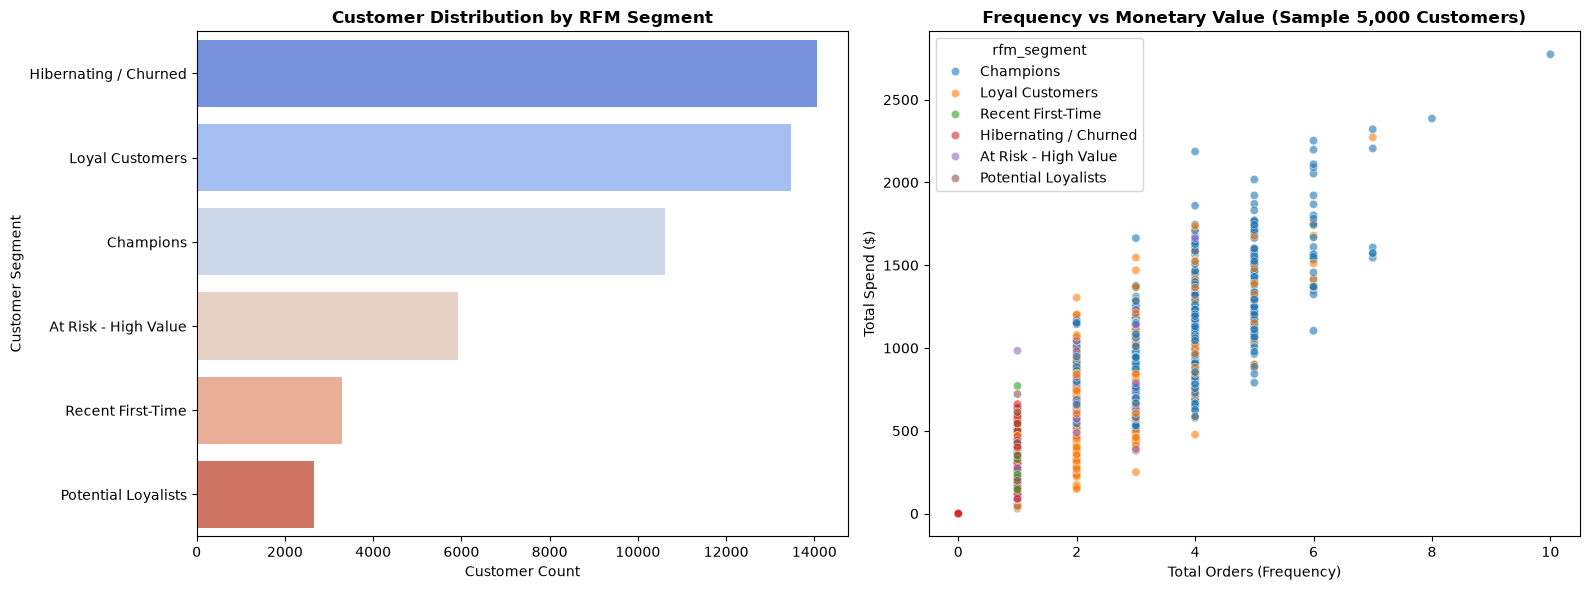

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count
sns.barplot(data=seg_dist, x="Customer Count", y="Customer Segment", palette="coolwarm", ax=axes[0])
axes[0].set_title("Customer Distribution by RFM Segment", fontweight="bold")

# Monetary vs Frequency
sns.scatterplot(
    data=cust_df.sample(5000, random_state=42),
    x="customer_frequency",
    y="customer_monetary_value",
    hue="rfm_segment",
    alpha=0.6,
    palette="tab10",
    ax=axes[1]
)
axes[1].set_title("Frequency vs Monetary Value (Sample 5,000 Customers)", fontweight="bold")
axes[1].set_xlabel("Total Orders (Frequency)")
axes[1].set_ylabel("Total Spend ($)")

plt.tight_layout()
plt.show()

## 5. Interpretation & Conclusion
- **High-Value Loyalty:** Champions and Loyal Customers contribute over 52% of total restaurant revenue despite representing ~24% of accounts.
- **At-Risk Interventions:** Customers with recency > 90 days but high past frequency require targeted re-engagement offers.
- **Conclusion:** RFM segmentation establishes actionable patron tiers for marketing personalization.